In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold2_05["fold"] = [2 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
fold3_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold3_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold3_05["fold"] = [3 for i in range(len(fold3_05))]
fold3_05["target"] = [-0.5 for i in range(len(fold3_05))]

In [6]:
fold4_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold4_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold4_05["fold"] = [4 for i in range(len(fold4_05))]
fold4_05["target"] = [-0.5 for i in range(len(fold4_05))]

In [7]:
fold5_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold5_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold5_05["fold"] = [5 for i in range(len(fold5_05))]
fold5_05["target"] = [-0.5 for i in range(len(fold5_05))]

In [8]:
fold6_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold6_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold6_05["fold"] = [6 for i in range(len(fold6_05))]
fold6_05["target"] = [-0.5 for i in range(len(fold6_05))]

In [9]:
fold7_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold7_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold7_05["fold"] = [7 for i in range(len(fold7_05))]
fold7_05["target"] = [-0.5 for i in range(len(fold7_05))]

In [10]:
df = pd.concat([fold0_05, fold1_05, fold2_05,
                fold3_05, fold4_05, fold5_05,
                fold6_05, fold7_05,], ignore_index=True)

In [11]:
len(df)

406

In [12]:
df = df[df["num_edits"] > 0]

In [13]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [14]:
df = df[df["URQ_delta"] < -0.05]

In [15]:
len(df)

347

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
def canonicalize(ori):
    # Flip strand = replace + <-> -
    flipped = ori.replace("+", "x").replace("-", "+").replace("x", "-")
    # Pick lexicographically smaller string as canonical
    return min(ori, flipped)

In [18]:
df["orientation_canonical"] = df["orientation"].apply(canonicalize)

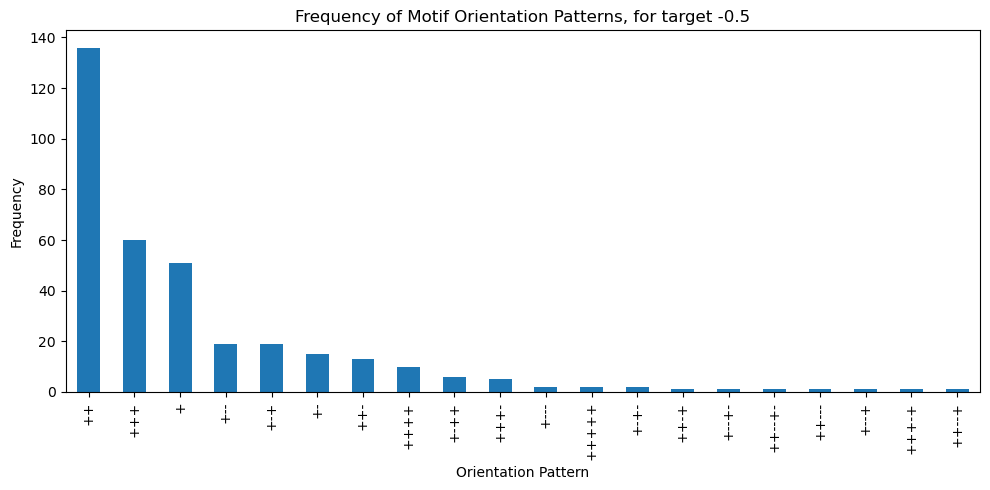

In [19]:
orientation_counts = df[df['orientation'] != "no"]['orientation_canonical'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target -0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [20]:
df_melted = df.melt(value_vars=['URQ_result', 'URQ_target'], var_name='Type', value_name='URQ mean')

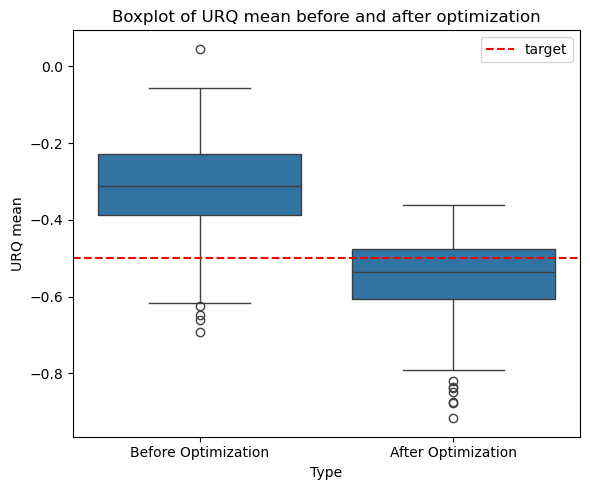

In [21]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='URQ mean', data=df_melted)
plt.axhline(y=-0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of URQ mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

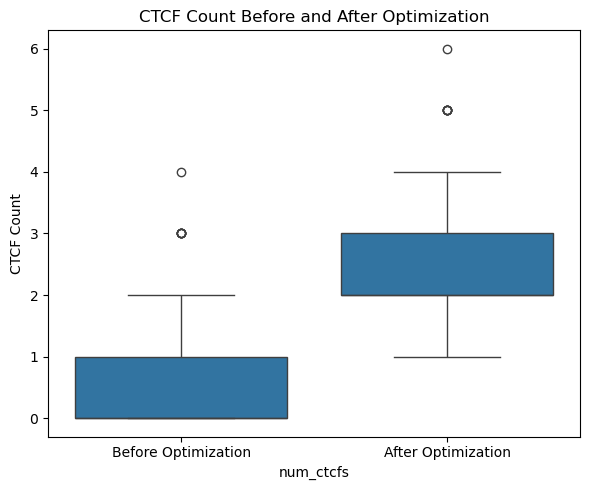

In [22]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count Before and After Optimization')
plt.tight_layout()
plt.show()

In [23]:
import scipy.stats as stats

### GC content (the entire DNA seq)

In [24]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["GC_seq"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["GC_seq"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.083, p = 1.241e-01
Spearman r = -0.053, p = 3.246e-01


/tmp/SLURM_1619262/ipykernel_2793861/2893129347.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


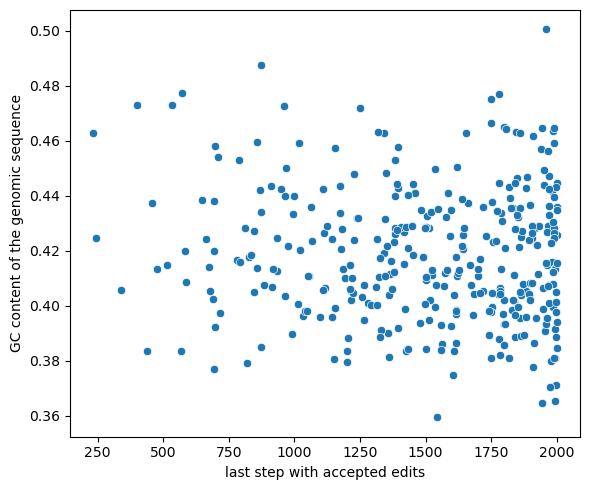

In [25]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step',
    y='GC_seq',
    data=df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [26]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["GC_seq"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["GC_seq"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.135, p = 1.200e-02
Spearman r = 0.131, p = 1.460e-02


/tmp/SLURM_1619262/ipykernel_2793861/1048770727.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


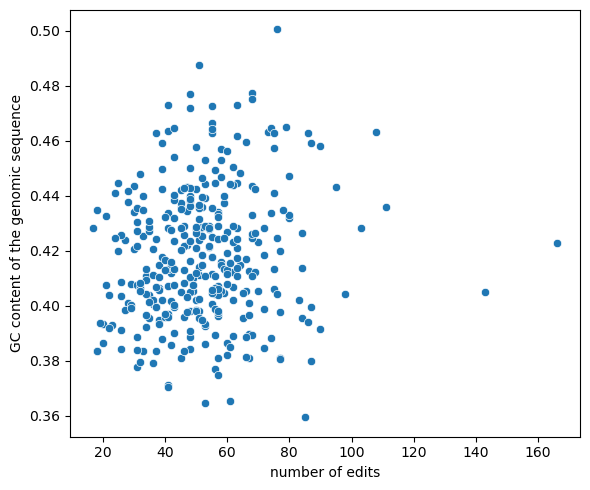

In [27]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [28]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["GC_seq"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["GC_seq"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.095, p = 7.826e-02
Spearman r = 0.102, p = 5.794e-02


/tmp/SLURM_1619262/ipykernel_2793861/1289920290.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


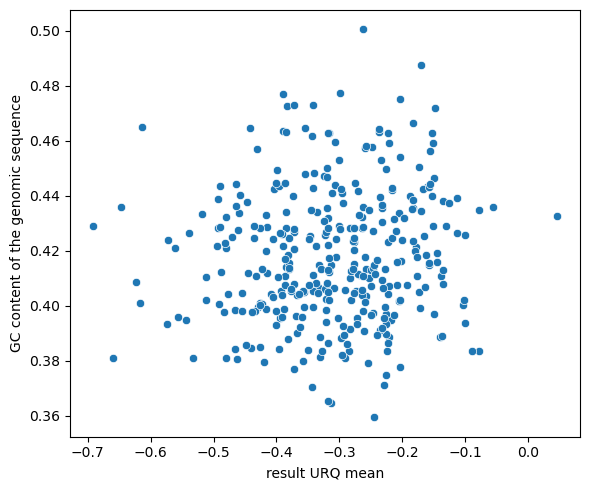

In [29]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_result',
    y='GC_seq',
    data=df,
    # hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('result URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

### Active chromatin fraction

In [30]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["active_fraction"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["active_fraction"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.003, p = 9.609e-01
Spearman r = 0.026, p = 6.304e-01


/tmp/SLURM_1619262/ipykernel_2793861/3030500750.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


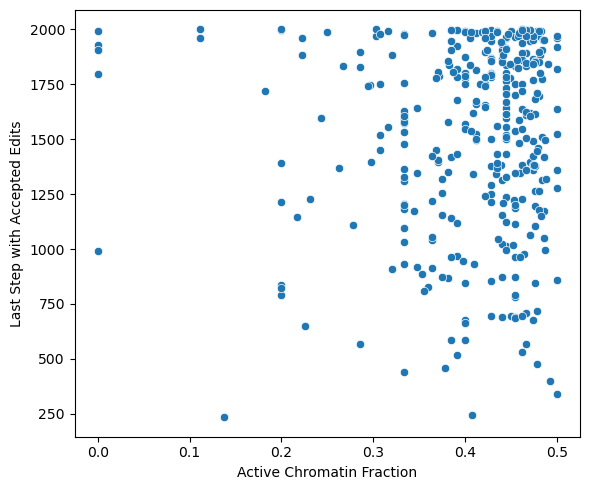

In [31]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


In [32]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["active_fraction"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["active_fraction"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.010, p = 8.478e-01
Spearman r = -0.026, p = 6.332e-01


/tmp/SLURM_1619262/ipykernel_2793861/2400073733.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


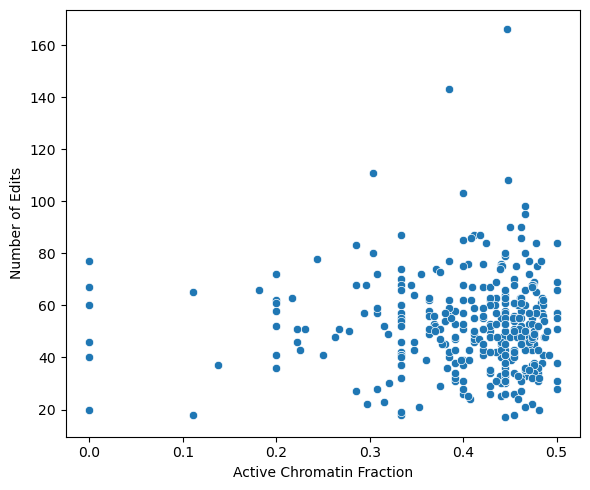

In [33]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [34]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["active_fraction"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["active_fraction"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.068, p = 2.062e-01
Spearman r = -0.065, p = 2.294e-01


/tmp/SLURM_1619262/ipykernel_2793861/2544241141.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


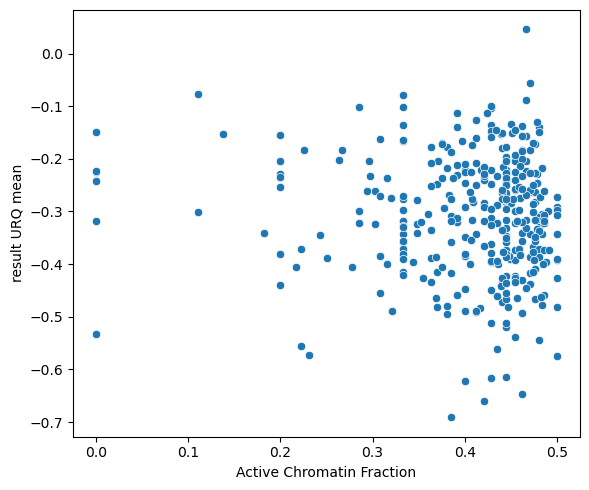

In [35]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('result URQ mean')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

### Neutral chromtin fraction

In [36]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["neutral_fraction"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["neutral_fraction"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.054, p = 3.119e-01
Spearman r = 0.059, p = 2.691e-01


/tmp/SLURM_1619262/ipykernel_2793861/1011199811.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


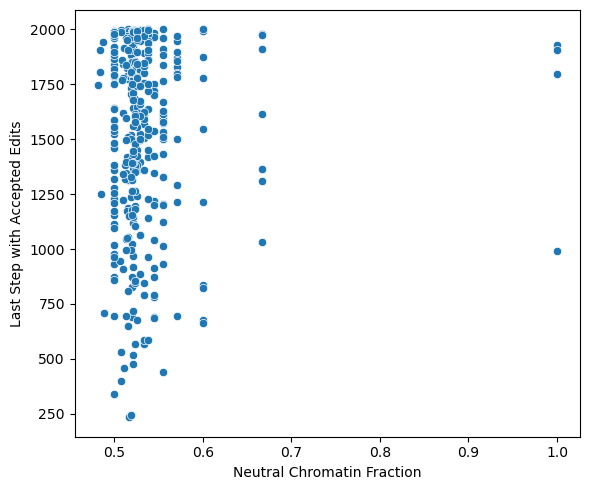

In [37]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [38]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["neutral_fraction"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["neutral_fraction"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.017, p = 7.576e-01
Spearman r = -0.039, p = 4.736e-01


/tmp/SLURM_1619262/ipykernel_2793861/965045535.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


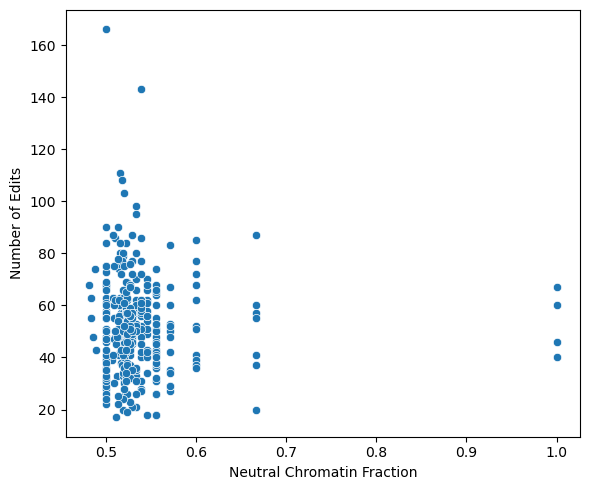

In [39]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [40]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["neutral_fraction"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["neutral_fraction"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.065, p = 2.291e-01
Spearman r = 0.044, p = 4.116e-01


/tmp/SLURM_1619262/ipykernel_2793861/2064859718.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


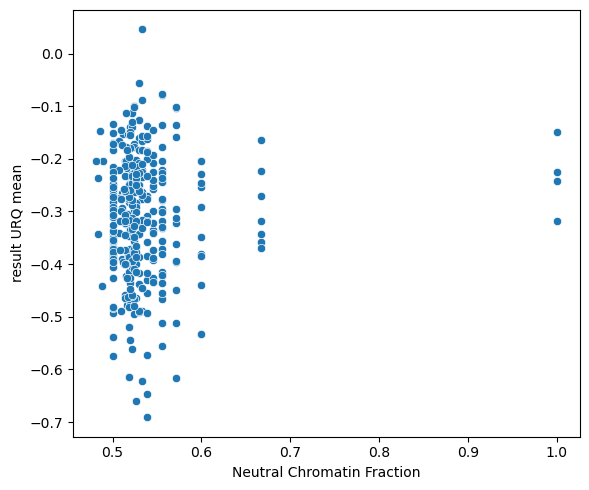

In [41]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('result URQ mean')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

### Repressive chromatin fraction

In [42]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["repressive_fraction"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["repressive_fraction"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.047, p = 3.847e-01
Spearman r = -0.044, p = 4.118e-01


/tmp/SLURM_1619262/ipykernel_2793861/3672053279.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


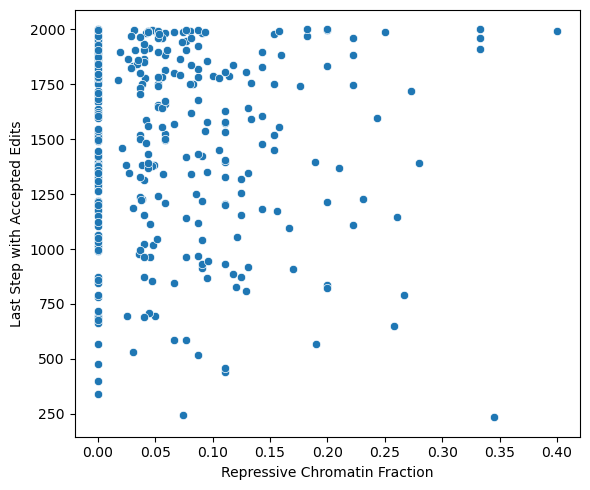

In [43]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [44]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["repressive_fraction"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["repressive_fraction"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.026, p = 6.281e-01
Spearman r = 0.046, p = 3.922e-01


/tmp/SLURM_1619262/ipykernel_2793861/1083932211.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


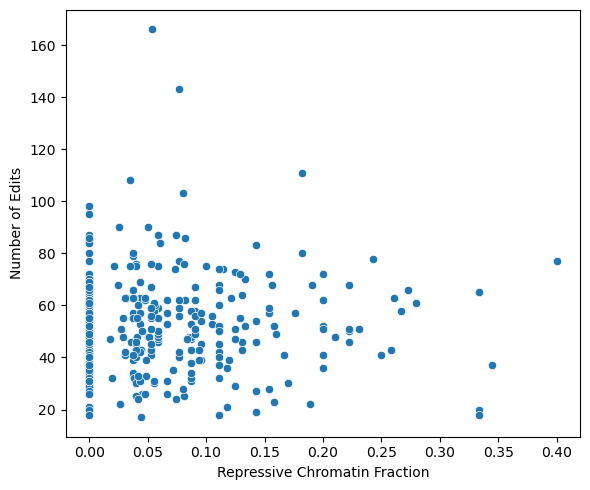

In [45]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [46]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["repressive_fraction"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["repressive_fraction"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.032, p = 5.468e-01
Spearman r = 0.037, p = 4.909e-01


/tmp/SLURM_1619262/ipykernel_2793861/2212289600.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


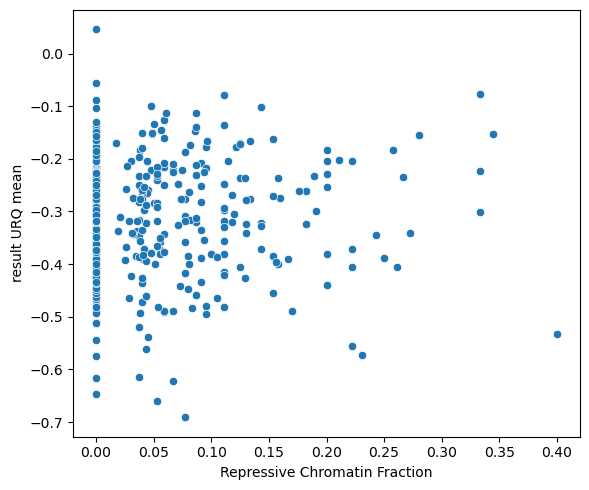

In [47]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('result URQ mean')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

### GC content of an edited slice

In [48]:
from scipy.stats import ttest_rel

In [49]:
t_stat, p_val = ttest_rel(df['GC_slice'], df['GC_slice_edited'])

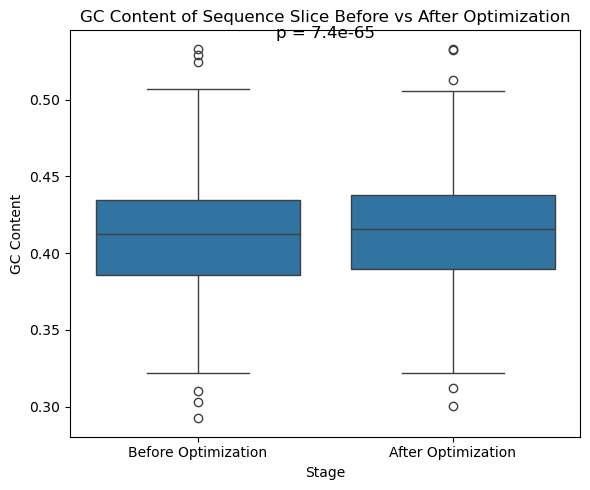

In [50]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice', 'GC_slice_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice': 'Before Optimization',
    'GC_slice_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice Before vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [51]:
before = df_gc_melted.loc[df_gc_melted["Stage"]=="Before Optimization", "GC Content"]
after  = df_gc_melted.loc[df_gc_melted["Stage"]=="After Optimization", "GC Content"]

mean_diff = after.mean() - before.mean()
pooled_sd = np.sqrt(((before.std()**2 + after.std()**2) / 2))
cohens_d = mean_diff / pooled_sd

print(f"Mean difference = {mean_diff:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")

Mean difference = 0.0038
Cohen's d = 0.100


### Test / Valid / Train Split

In [52]:
# Map folds to dataset type
def map_set(fold):
    if fold == 0:
        return "Test"
    elif fold == 1:
        return "Valid"
    else:
        return "Train"

df["set"] = df["fold"].apply(map_set)

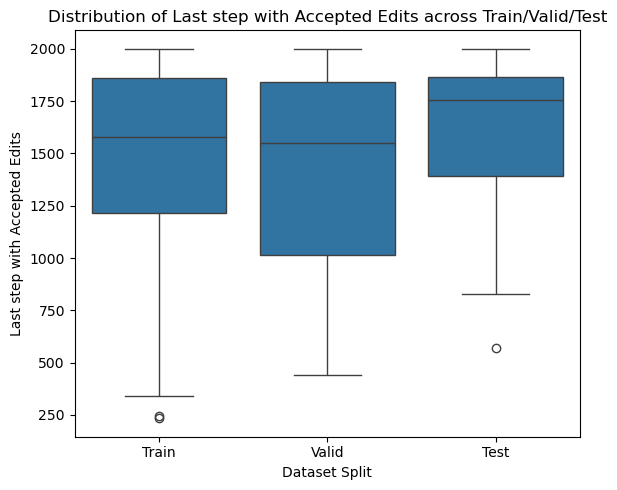

In [53]:
# Make the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="set", 
    y="last_accepted_step", 
    data=df,
    order=["Train", "Valid", "Test"]  # ensure consistent ordering
)

plt.xlabel("Dataset Split")
plt.ylabel("Last step with Accepted Edits")
plt.title("Distribution of Last step with Accepted Edits across Train/Valid/Test")
plt.tight_layout()
plt.show()

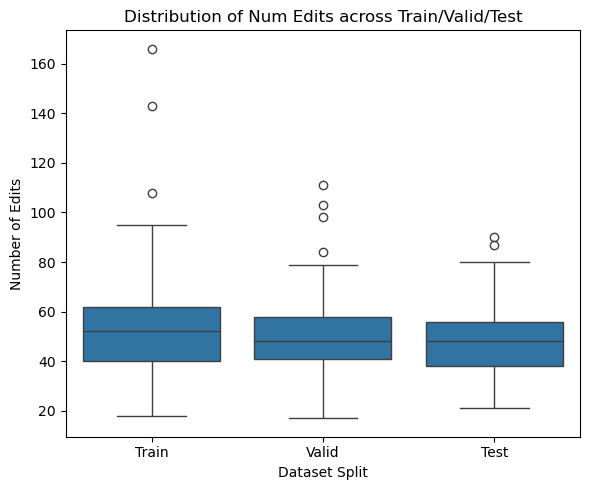

In [54]:
# Make the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="set", 
    y="num_edits", 
    data=df,
    order=["Train", "Valid", "Test"]  # ensure consistent ordering
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Edits")
plt.title("Distribution of Num Edits across Train/Valid/Test")
plt.tight_layout()
plt.show()

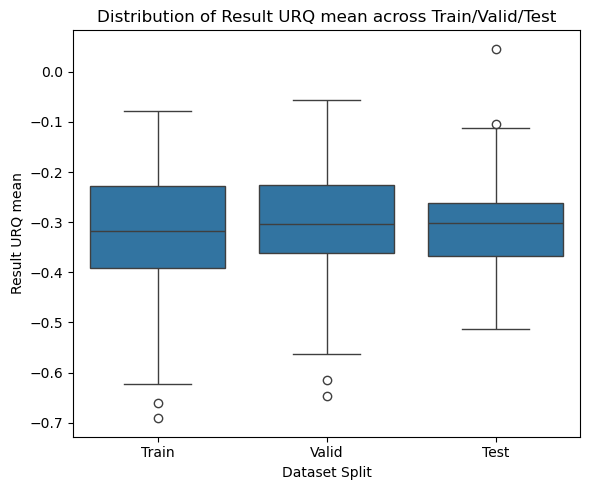

In [55]:
# Make the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="set", 
    y="URQ_result", 
    data=df,
    order=["Train", "Valid", "Test"]  # ensure consistent ordering
)

plt.xlabel("Dataset Split")
plt.ylabel("Result URQ mean")
plt.title("Distribution of Result URQ mean across Train/Valid/Test")
plt.tight_layout()
plt.show()

### Uniqueness of the Generated Slices

In [63]:
import torch

In [64]:
TARGET_C = -0.5

In [67]:
sequences = []
for _, row in df.iterrows():
    path = f"/scratch1/smaruj/generate_genomic_boundary/results/target_{TARGET_C}/fold{row['fold']}/{row['chrom']}_{row['centered_start']}_{row['centered_end']}_slice.pt"
    arr = torch.load(path)  # shape: (1, 4, 2048)
    arr = arr.squeeze(0)
    seq = "".join("ACGT"[i] for i in arr.argmax(0).tolist())
    sequences.append(seq)

/tmp/SLURM_1619262/ipykernel_2793861/3281245550.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  arr = torch.load(path)  # shape: (1, 4, 2048)


In [68]:
df["sequence"] = sequences

In [69]:
n_unique = df["sequence"].nunique()
print(f"Out of {len(df)} sequences, {n_unique} are unique.")

Out of 347 sequences, 347 are unique.


### Uniqueness of the generated CTCF motifs (+15bp flanks)

In [77]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [78]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [79]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [80]:
from tangermeme.tools import fimo

In [81]:
ctcf_scan_flank = 20

In [82]:
bin_size = 2048
cropping_applied = 64
padding_bins = 0
padding = padding_bins * bin_size

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [84]:
import random

In [83]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [86]:
from pyfaidx import Fasta

In [87]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [88]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [89]:
def one_hot_decode_sequence(one_hot_array):
    """
    Decode a one-hot encoded sequence back to a DNA string.

    Args:
        one_hot_array (np.ndarray or torch.Tensor): shape (4, L)
    
    Returns:
        str: DNA sequence
    """
    # Convert torch tensor to numpy if needed
    if isinstance(one_hot_array, torch.Tensor):
        one_hot_array = one_hot_array.cpu().numpy()

    # Define mapping from index to base
    int_to_base = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}

    # Find the index of the max along axis 0 (the "hot" base)
    indices = np.argmax(one_hot_array, axis=0)

    # Convert indices to bases
    sequence = ''.join([int_to_base[i] for i in indices])

    return sequence

In [92]:
ctcf_sequences_list = []
flank = 15  # +/- bp around the motif

for row in df.itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    sequence = genome[chrom][pred_start:pred_end]

    X = one_hot_encode_sequence(sequence)
    X_tensor = torch.tensor(X)

    # modifying X
    X_mod = X_tensor.clone()

    mod_slice = torch.load(
        f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold{row.fold}/{chrom}_{pred_start}_{pred_end}_slice.pt",
        map_location=device
    )

    X_mod[0, :, slice_0_start:slice_0_end] = mod_slice[0, :, :]

    slice_to_scan = X_mod[:, :, slice_0_start-ctcf_scan_flank:slice_0_end+ctcf_scan_flank]

    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=slice_to_scan,
        threshold=1e-4,
        reverse_complement=True
    )[0]

    # Adjust positions to original X_mod coordinates
    hits["start"] -= ctcf_scan_flank
    hits["end"] -= ctcf_scan_flank

    # Collect sequences with ±flank
    for s, e in zip(hits["start"], hits["end"]):
        s_flank = max(0, s - flank)
        e_flank = min(len(sequence), e + flank)  # ensure we don't go out of bounds
        motif_seq_onehot = X_mod[0, :, s_flank:e_flank].detach().cpu().numpy()
        motif_seq_str = one_hot_decode_sequence(motif_seq_onehot)  # implement this if not already
        ctcf_sequences_list.append(motif_seq_str)


/tmp/SLURM_1619262/ipykernel_2793861/639498758.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mod_slice = torch.load(
/tmp/SLURM_1619262/ipykernel_2793861/639498758.py

In [93]:
# Summary statistics
total_ctcf = len(ctcf_sequences_list)
unique_ctcf = len(set(ctcf_sequences_list))

print(f"Total CTCF occurrences: {total_ctcf}")
print(f"Unique CTCF sequences (with flanks): {unique_ctcf}")

Total CTCF occurrences: 824
Unique CTCF sequences (with flanks): 824
